# 📊 FIAP - Feature Engineering
## EDA - Análise Exploratória de Dados

---

### 📋 **Informações do Projeto**
- **Curso:** Pós-graduação em Data Science & Artificial Intelligence
- **Disciplina:** Feature Engineering
- **Aula:** 3 - Redução de Dimensionalidade, Balanceamento e EDA
- **Autor:** Filipe Pacheco

---

### 🎯 **Objetivos do Projeto**
Este notebook demonstra técnicas fundamentais de Análise Exploratória de Dados (EDA) aplicadas ao dataset Iris:
- **Análise Descritiva:** Estatísticas e informações gerais do dataset
- **Visualizações:** Distribuições, correlações e padrões nos dados
- **Análise por Classes:** Comparação das variáveis entre diferentes espécies
- **Feature Engineering:** Transformações e criação de novas features
- **PCA:** Redução de dimensionalidade para visualização

---

### 📊 **Dataset Utilizado**
**Iris Dataset** - Medidas morfológicas de flores do gênero Iris
- **Fonte:** UCI Machine Learning Repository - Iris Dataset
- **Registros:** 150 observações de características florais
- **Features:** 4 variáveis numéricas (sepal_length, sepal_width, petal_length, petal_width)
- **Target:** 3 classes de espécies (Iris-setosa, Iris-versicolor, Iris-virginica)
- **Aplicação:** Classificação multiclasse e análise exploratória

---

# 1 Importação das Bibliotecas

In [1]:
# =============================================================================
# BIBLIOTECAS DE MANIPULAÇÃO E ANÁLISE DE DADOS
# =============================================================================
import pandas as pd              # Manipulação e análise de dados estruturados (DataFrames)
import numpy as np               # Operações matemáticas e arrays multidimensionais

# =============================================================================
# BIBLIOTECAS DE MACHINE LEARNING - SCIKIT-LEARN
# =============================================================================
from sklearn.decomposition import PCA  # Análise de Componentes Principais (PCA)

# =============================================================================
# BIBLIOTECAS DE VISUALIZAÇÃO
# =============================================================================
import matplotlib.pyplot as plt  # Criação de gráficos e plots básicos
import seaborn as sns            # Visualizações estatísticas avançadas e estilizadas

# =============================================================================
# CONFIGURAÇÕES GERAIS
# =============================================================================
# Configurar estilo dos gráficos
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")          # Configurar paleta de cores
plt.rcParams['figure.figsize'] = (12, 6)  # Configurar tamanho padrão das figuras

# Configurações para exibição
pd.set_option('display.max_columns', None)  # Mostrar todas as colunas
pd.set_option('display.width', None)        # Não limitar largura da exibição

# 2 Carregamento e Inspeção do Dataset

## 2.1 Descrição do Dataset

Para este exemplo, utilizaremos o famoso dataset "Iris". Este dataset é um dos conjuntos de dados mais clássicos e amplamente utilizados em machine learning e estatística. Ele contém medidas de várias características de flores do gênero Iris e é frequentemente usado para demonstrar técnicas de classificação e análise de dados.

- Principais Características do Dataset:
    - sepal_length: Comprimento da sépala em centímetros.
    - sepal_width: Largura da sépala em centímetros.
    - petal_length: Comprimento da pétala em centímetros.
    - petal_width: Largura da pétala em centímetros.
    - species: Espécie da flor Iris (Setosa, Versicolor, ou Virginica).

- Importância das Variáveis:
    - Comprimento da Sépla (sepal_length) e Largura da Sépla (sepal_width): Estas medidas ajudam a identificar características gerais da flor e são usadas para diferenciar entre espécies.
    - Comprimento da Pétila (petal_length) e Largura da Pétila (petal_width): Essas medidas são cruciais para identificar a espécie específica de Iris, pois as pétalas podem variar mais significativamente entre as espécies.
    - Espécie (species): A variável alvo que estamos tentando prever. As três espécies de Iris no dataset são Iris-setosa, Iris-versicolor e Iris-virginica.

- Fonte do Dataset:
    - O dataset Iris está originalmente disponível em: Iris Dataset no UCI Machine Learning Repository.
    - Para carregar o dataset em um DataFrame do pandas:
        url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
        
        columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']

        df = pd.read_csv(url, names=columns)

In [2]:
# Carregando o dataset
df = pd.read_csv("datasets/iris.csv")

In [3]:
# Exibindo as primeiras linhas do dataset
df.head()

,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


# 3 Análise Exploratória dos Dados

## 3.1 Informações Gerais

In [4]:
# Informações gerais sobre o dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   class         150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


## 3.2 Estatísticas Descritivas

In [5]:
# Estatísticas descritivas
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## 3.3 Análise das Variáveis Independentes

### 3.3.1 Distribuição das Variáveis Numéricas

Aqui, usamos histogramas para visualizar a distribuição das variáveis numéricas. A função kde=True adiciona uma estimativa da densidade de probabilidade para ver a forma da distribuição.

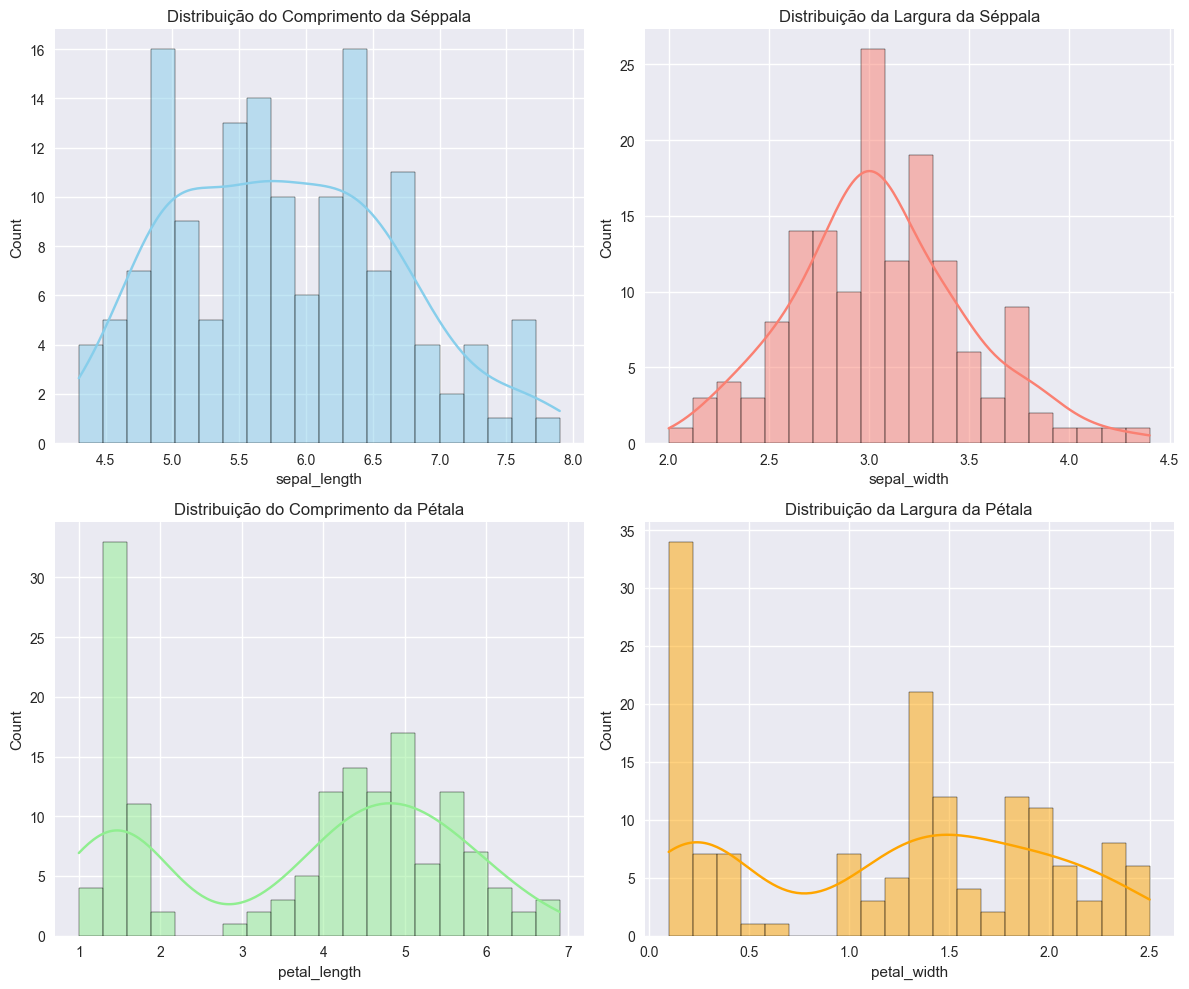

In [6]:
# Distribuição das variáveis numéricas
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
sns.histplot(df['sepal_length'], kde=True, bins=20, color='skyblue')
plt.title('Distribuição do Comprimento da Séppala')

plt.subplot(2, 2, 2)
sns.histplot(df['sepal_width'], kde=True, bins=20, color='salmon')
plt.title('Distribuição da Largura da Séppala')

plt.subplot(2, 2, 3)
sns.histplot(df['petal_length'], kde=True, bins=20, color='lightgreen')
plt.title('Distribuição do Comprimento da Pétala')

plt.subplot(2, 2, 4)
sns.histplot(df['petal_width'], kde=True, bins=20, color='orange')
plt.title('Distribuição da Largura da Pétala')

plt.tight_layout()
plt.show()

### 3.3.2 Relação entre Variáveis Numéricas

Usamos gráficos de dispersão para visualizar a relação entre pares de variáveis numéricas. Cada gráfico é colorido pelas classes para ver como as variáveis se comportam em relação às diferentes espécies de íris.

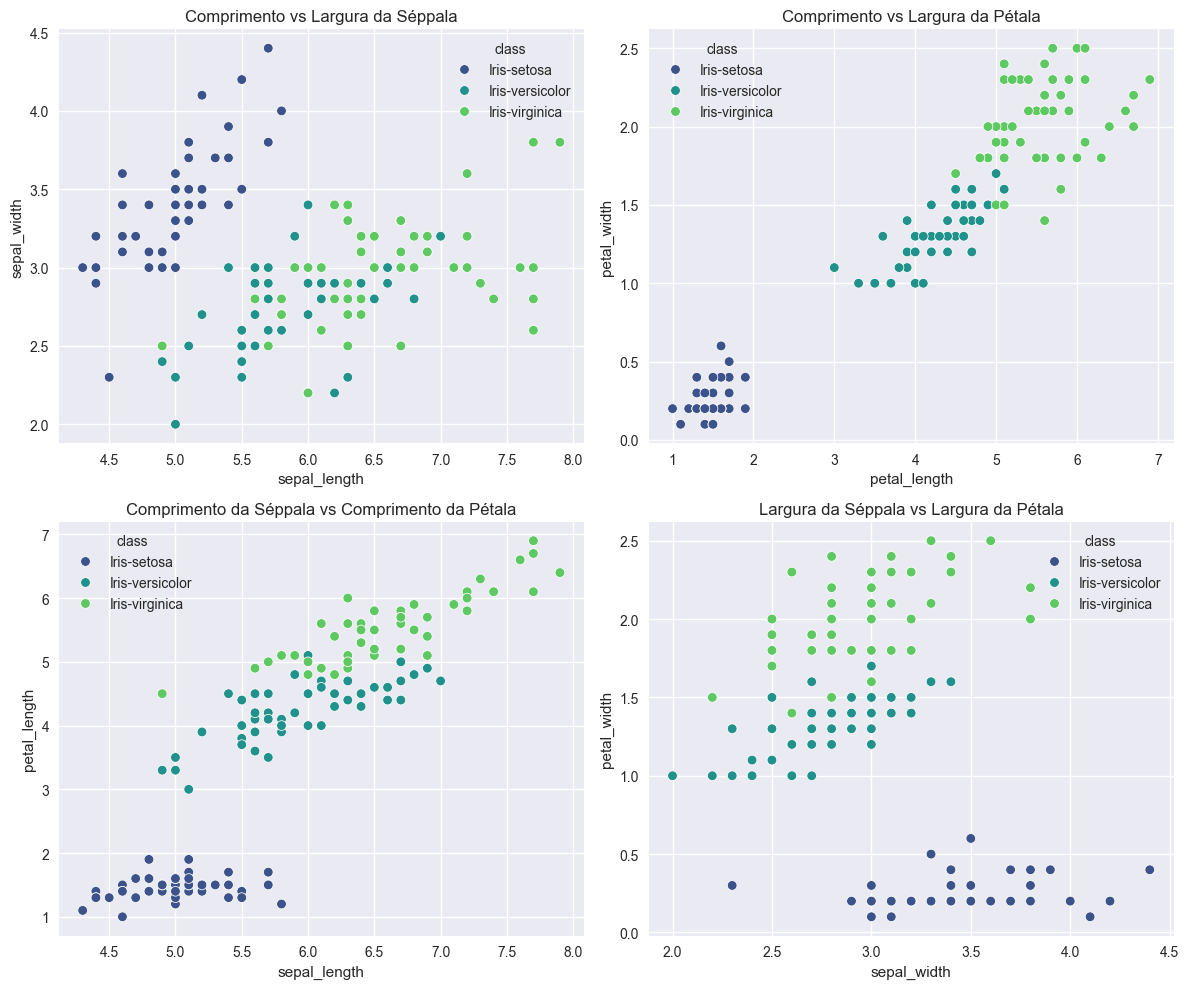

In [7]:
# Relação entre variáveis numéricas
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
sns.scatterplot(data=df, x='sepal_length', y='sepal_width', hue='class', palette='viridis')
plt.title('Comprimento vs Largura da Séppala')

plt.subplot(2, 2, 2)
sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='class', palette='viridis')
plt.title('Comprimento vs Largura da Pétala')

plt.subplot(2, 2, 3)
sns.scatterplot(data=df, x='sepal_length', y='petal_length', hue='class', palette='viridis')
plt.title('Comprimento da Séppala vs Comprimento da Pétala')

plt.subplot(2, 2, 4)
sns.scatterplot(data=df, x='sepal_width', y='petal_width', hue='class', palette='viridis')
plt.title('Largura da Séppala vs Largura da Pétala')

plt.tight_layout()
plt.show()

### 3.3.4 Correlação entre Variáveis

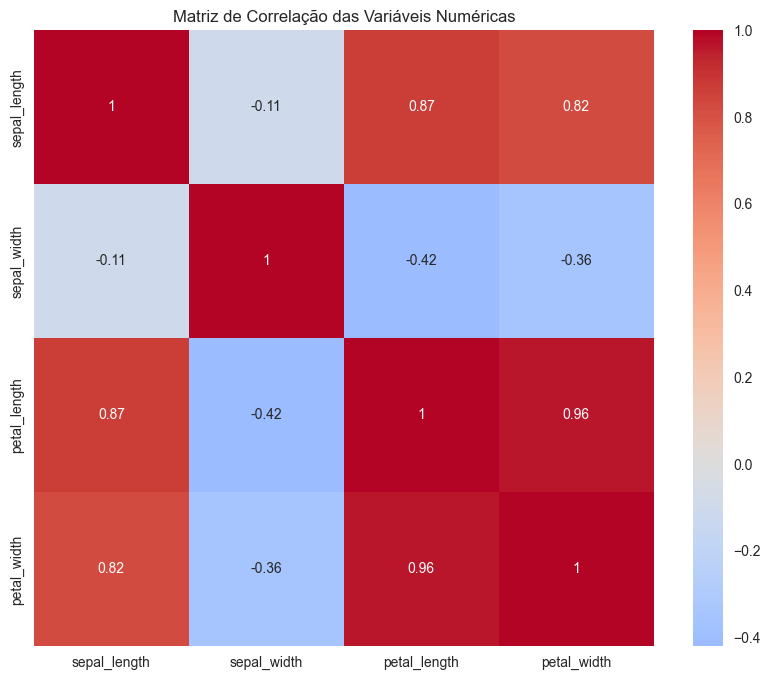

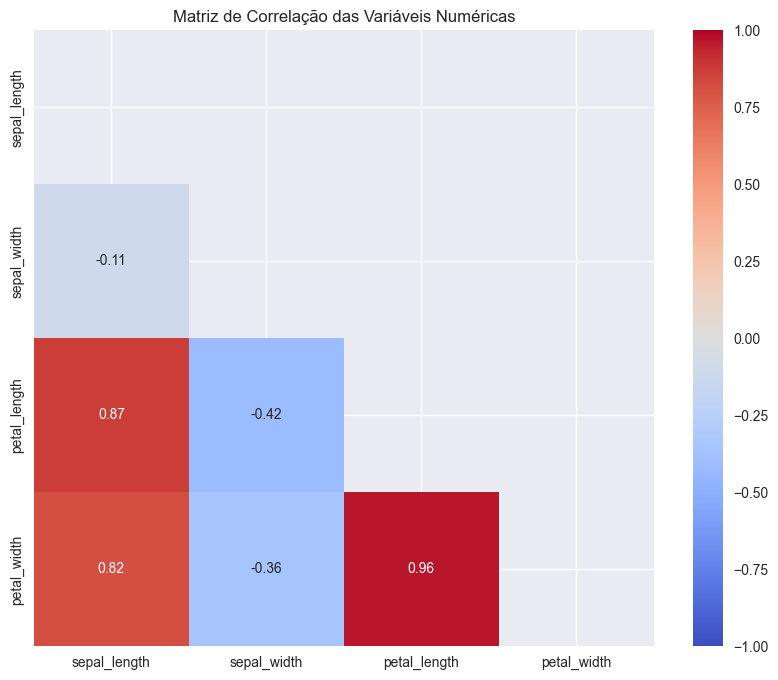

In [8]:
# Correlações entre as variáveis numéricas
plt.figure(figsize=(10, 8))
sns.heatmap(df.drop('class', axis=1).corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlação das Variáveis Numéricas')
plt.show()

# Plotando a matriz de correlação com a máscara
mask = np.triu(np.ones_like(df.drop('class', axis=1).corr(), dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(df.drop('class', axis=1).corr(), annot=True, mask=mask, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Matriz de Correlação das Variáveis Numéricas')
plt.show()

## 3.4 Relação entre Variáveis e a Variável Alvo

### 3.4.1 Boxplots das Variáveis por Classe e análise de Outliers

Os boxplots mostram a distribuição das variáveis numéricas para cada classe. Eles ajudam a visualizar a mediana, quartis e possíveis outliers, e como as variáveis variam entre diferentes classes.

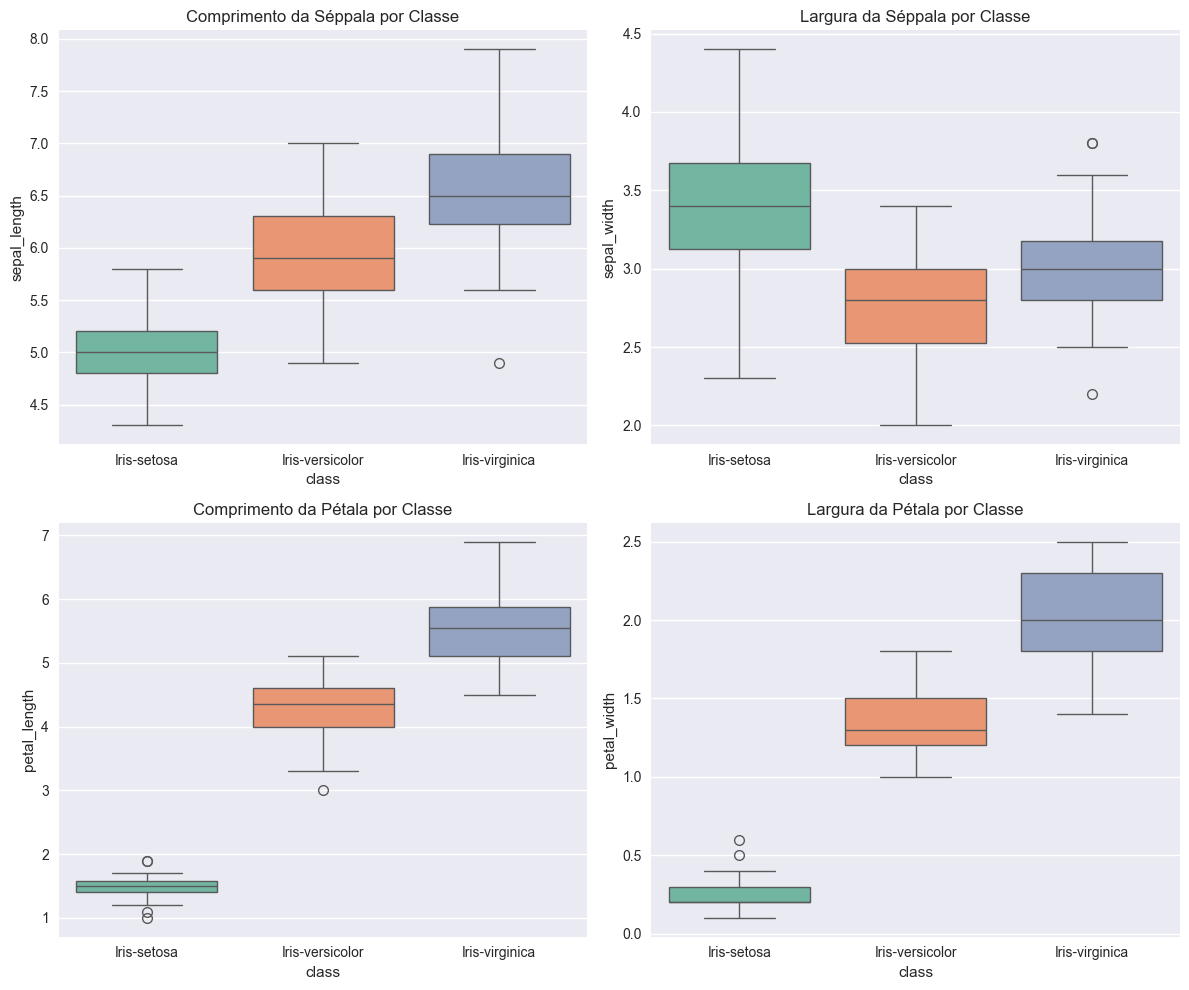

In [9]:
# Boxplots das variáveis numéricas por classe
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
sns.boxplot(data=df, x='class', hue='class', y='sepal_length', palette='Set2', legend=False)
plt.title('Comprimento da Séppala por Classe')

plt.subplot(2, 2, 2)
sns.boxplot(data=df, x='class', hue='class', y='sepal_width', palette='Set2', legend=False)
plt.title('Largura da Séppala por Classe')

plt.subplot(2, 2, 3)
sns.boxplot(data=df, x='class', hue='class', y='petal_length', palette='Set2', legend=False)
plt.title('Comprimento da Pétala por Classe')

plt.subplot(2, 2, 4)
sns.boxplot(data=df, x='class', hue='class', y='petal_width', palette='Set2', legend=False)
plt.title('Largura da Pétala por Classe')

plt.tight_layout()
plt.show()

### 3.4.2 Pairplots para Visualização das Relações

Pairplots mostram todas as combinações de variáveis numéricas e a relação entre elas. É útil para visualizar como cada variável se relaciona com as outras e com a variável alvo.

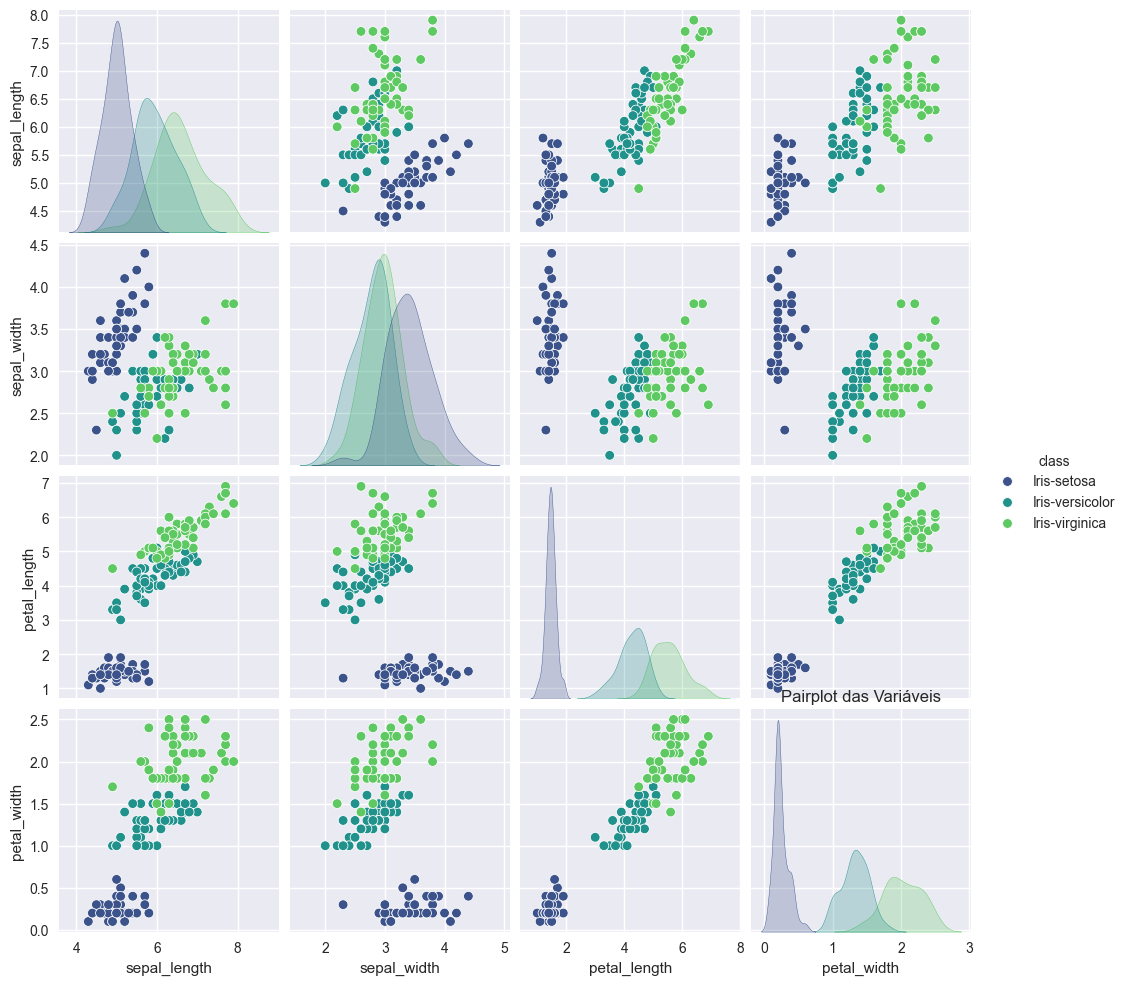

In [10]:
# Pairplots para visualizar relações entre variáveis e a variável alvo
sns.pairplot(df, hue='class', palette='viridis')
plt.title('Pairplot das Variáveis')
plt.show()

###  3.4.3 Análise de Variáveis Categóricas

Gráficos de contagem ajudam a visualizar a distribuição das variáveis categóricas e verificar o balanceamento entre as categorias.

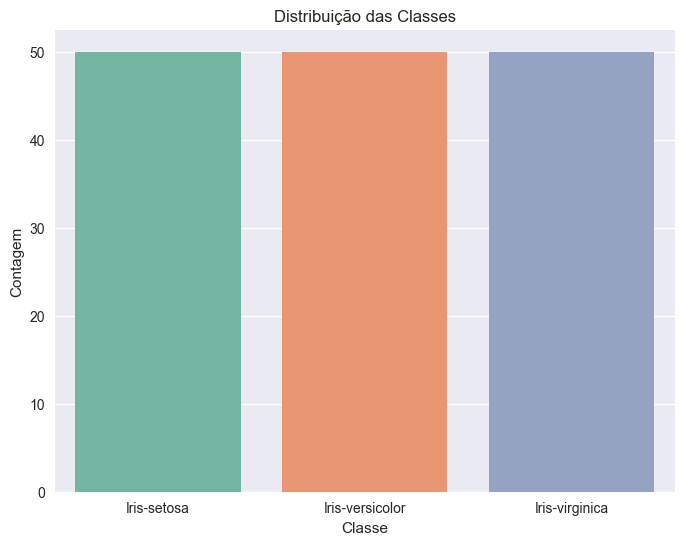

In [11]:
# Análise da distribuição das variáveis categóricas
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='class', hue='class', palette='Set2')
plt.title('Distribuição das Classes')
plt.xlabel('Classe')
plt.ylabel('Contagem')
plt.show()

## 3.5 Análises com Feature Engineering

### 3.5.1 Análises de Transformações de Dados

Transformações podem ajudar a estabilizar a variância e tornar os dados mais gaussianos, o que pode melhorar o desempenho dos modelos.

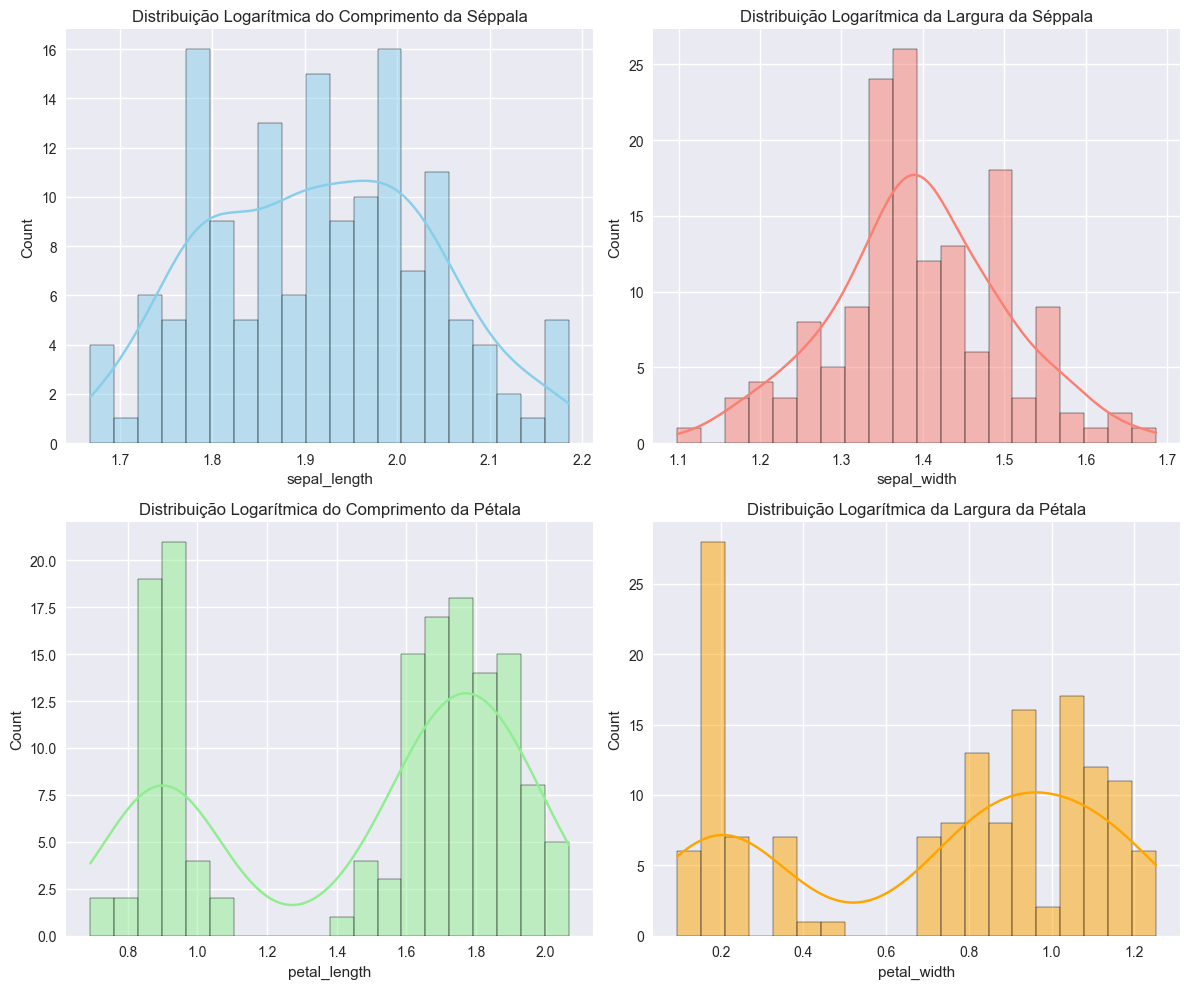

In [12]:
# Aplicando transformações logarítmicas
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
sns.histplot(np.log1p(df['sepal_length']), kde=True, bins=20, color='skyblue')
plt.title('Distribuição Logarítmica do Comprimento da Séppala')

plt.subplot(2, 2, 2)
sns.histplot(np.log1p(df['sepal_width']), kde=True, bins=20, color='salmon')
plt.title('Distribuição Logarítmica da Largura da Séppala')

plt.subplot(2, 2, 3)
sns.histplot(np.log1p(df['petal_length']), kde=True, bins=20, color='lightgreen')
plt.title('Distribuição Logarítmica do Comprimento da Pétala')

plt.subplot(2, 2, 4)
sns.histplot(np.log1p(df['petal_width']), kde=True, bins=20, color='orange')
plt.title('Distribuição Logarítmica da Largura da Pétala')

plt.tight_layout()
plt.show()

### 3.5.2 Análise de Distribuição de Variáveis Agrupadas

Comparar a distribuição das variáveis entre diferentes grupos pode revelar padrões e diferenças significativas entre as categorias.

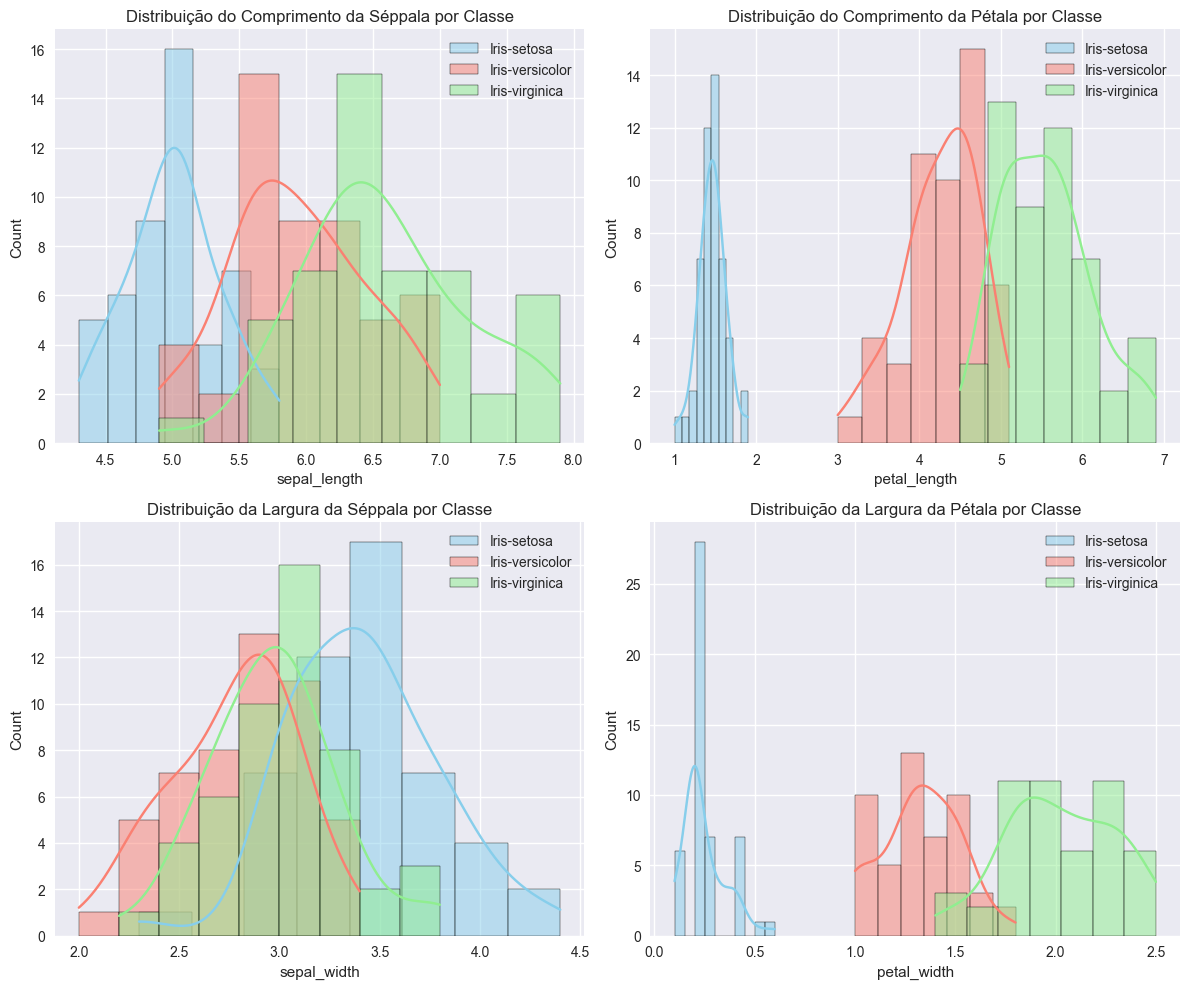

In [13]:
# Distribuição das variáveis por grupos
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
sns.histplot(df[df['class'] == 'Iris-setosa']['sepal_length'], kde=True, color='skyblue', label='Iris-setosa')
sns.histplot(df[df['class'] == 'Iris-versicolor']['sepal_length'], kde=True, color='salmon', label='Iris-versicolor')
sns.histplot(df[df['class'] == 'Iris-virginica']['sepal_length'], kde=True, color='lightgreen', label='Iris-virginica')
plt.title('Distribuição do Comprimento da Séppala por Classe')
plt.legend()

plt.subplot(2, 2, 2)
sns.histplot(df[df['class'] == 'Iris-setosa']['petal_length'], kde=True, color='skyblue', label='Iris-setosa')
sns.histplot(df[df['class'] == 'Iris-versicolor']['petal_length'], kde=True, color='salmon', label='Iris-versicolor')
sns.histplot(df[df['class'] == 'Iris-virginica']['petal_length'], kde=True, color='lightgreen', label='Iris-virginica')
plt.title('Distribuição do Comprimento da Pétala por Classe')
plt.legend()

plt.subplot(2, 2, 3)
sns.histplot(df[df['class'] == 'Iris-setosa']['sepal_width'], kde=True, color='skyblue', label='Iris-setosa')
sns.histplot(df[df['class'] == 'Iris-versicolor']['sepal_width'], kde=True, color='salmon', label='Iris-versicolor')
sns.histplot(df[df['class'] == 'Iris-virginica']['sepal_width'], kde=True, color='lightgreen', label='Iris-virginica')
plt.title('Distribuição da Largura da Séppala por Classe')
plt.legend()
 
plt.subplot(2, 2, 4)
sns.histplot(df[df['class'] == 'Iris-setosa']['petal_width'], kde=True, color='skyblue', label='Iris-setosa')
sns.histplot(df[df['class'] == 'Iris-versicolor']['petal_width'], kde=True, color='salmon', label='Iris-versicolor')
sns.histplot(df[df['class'] == 'Iris-virginica']['petal_width'], kde=True, color='lightgreen', label='Iris-virginica')
plt.title('Distribuição da Largura da Pétala por Classe')
plt.legend()
 

plt.tight_layout()
plt.show()


### 3.5.3 Análise de Distribuição com Gráficos de Densidade

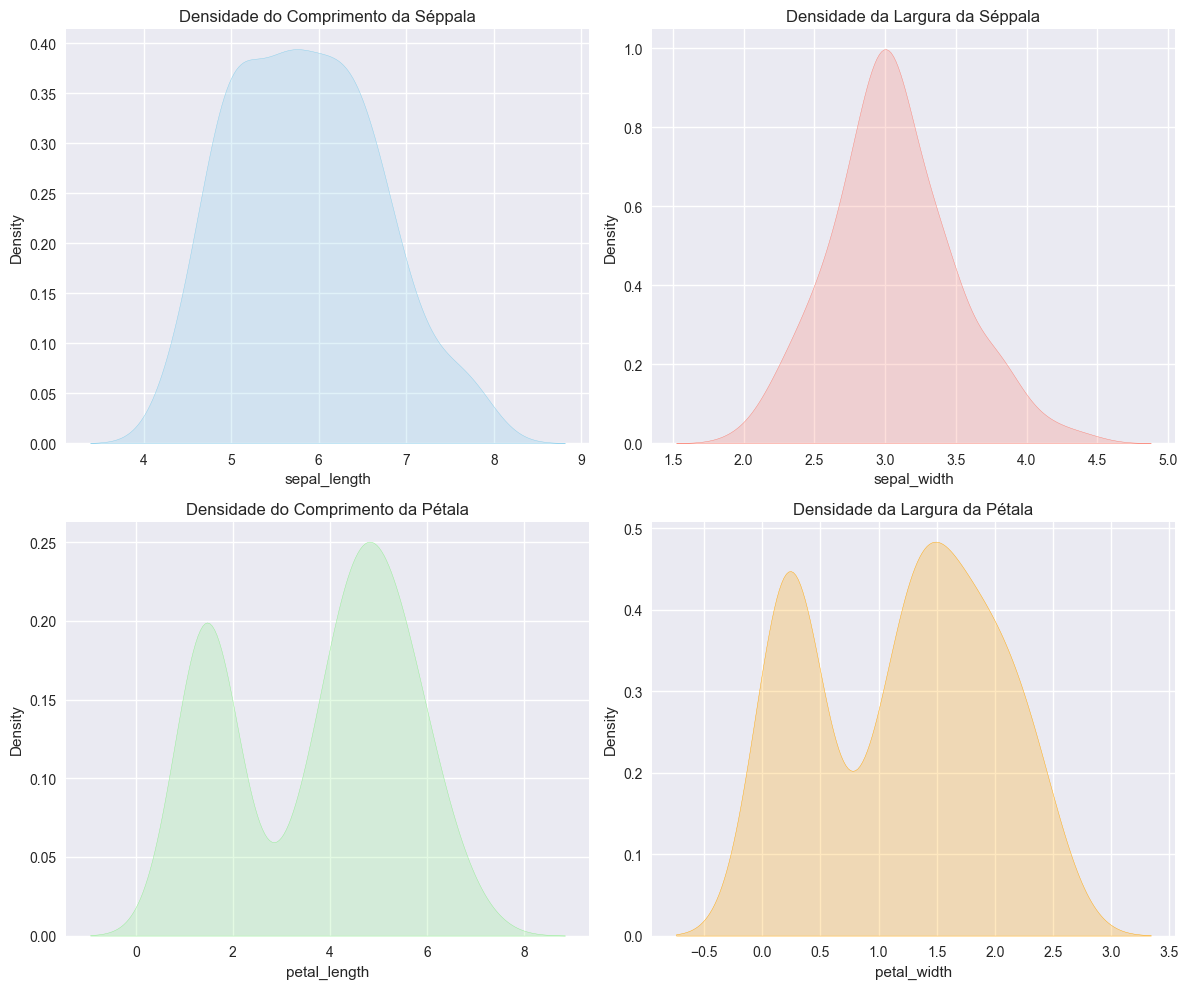

In [14]:
# Gráficos de densidade
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
sns.kdeplot(df['sepal_length'], fill=True, color='skyblue')
plt.title('Densidade do Comprimento da Séppala')

plt.subplot(2, 2, 2)
sns.kdeplot(df['sepal_width'], fill=True, color='salmon')
plt.title('Densidade da Largura da Séppala')

plt.subplot(2, 2, 3)
sns.kdeplot(df['petal_length'], fill=True, color='lightgreen')
plt.title('Densidade do Comprimento da Pétala')

plt.subplot(2, 2, 4)
sns.kdeplot(df['petal_width'], fill=True, color='orange')
plt.title('Densidade da Largura da Pétala')

plt.tight_layout()
plt.show()


### 3.5.4 Análise de Componentes Principais (PCA)

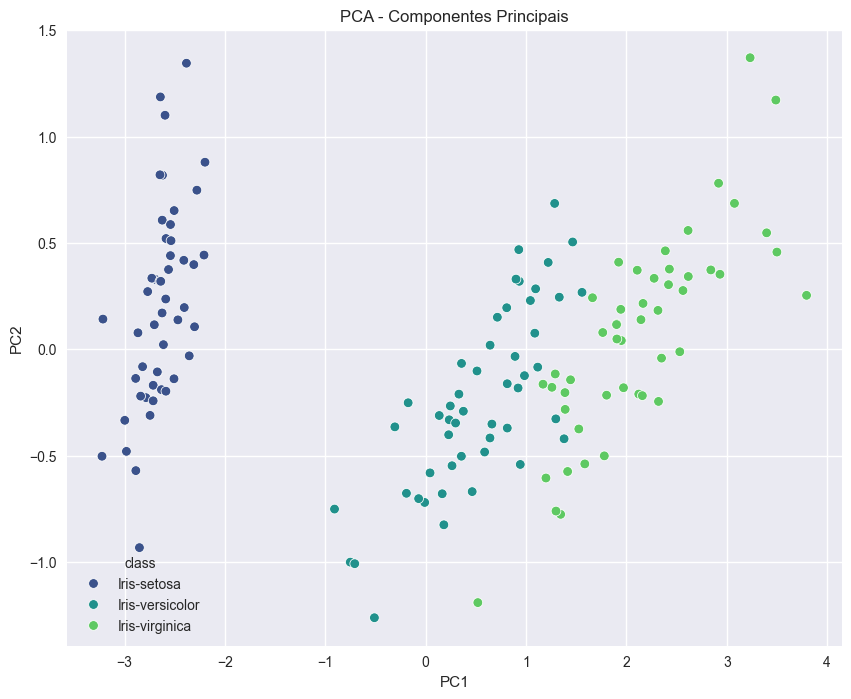

In [15]:
from sklearn.decomposition import PCA

# Aplicando PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df.drop('class', axis=1))

# Adicionando as componentes principais ao DataFrame
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['class'] = df['class']

# Visualizando os componentes principais
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='class', palette='viridis')
plt.title('PCA - Componentes Principais')
plt.show()